In [30]:
import random
from random import randint as ri
import time
import matplotlib.pyplot as plt

In [14]:
t1 = 5
t2 = 8

In [43]:
def generate_test_case ( total_vehicles ) :
    
    Vehicles = [ [] , [] ]

    total_time = 500
    for i in range ( total_vehicles ) :
        
        lane = ri(0,1)
        arrival_time = ri(0,total_time)
        fastest_time = ri(10,100)
        slowest_time = 10**7

        vehicle = [ arrival_time ,
                    arrival_time + fastest_time ,
                    arrival_time + slowest_time ] 
        
        Vehicles[lane].append(vehicle)

    for v in Vehicles :
        v.sort()
    
    return Vehicles

In [44]:
def calculate_dp ( Vehicles ) :
    
    n,m = len(Vehicles[0]) , len(Vehicles[1])

    D = [ [ [ 10**14 for k in range ( 2 ) ] for j in range ( m + 1 ) ] for i in range ( n + 1 ) ]

    D[0][0] = [ 0 , 0 ]

    for i in range ( n + 1 ) :
        for j in range ( m  + 1 ) :
            
            if i != 0 :
                D[i][j][0] = min ( D[i-1][j][0] + t1 , D[i-1][j][1] + t2 )
                D[i][j][0] = max ( D[i][j][0] , Vehicles[0][i-1][1] )
            
            if j != 0 :
                D[i][j][1] = min ( D[i][j-1][0] + t2 , D[i][j-1][1] + t1 )
                D[i][j][1] = max ( D[i][j][1] , Vehicles[1][j-1][1] )

    return min(D[n][m])

In [45]:
def calculate_adhoc ( Vehicles ) :
    
    Vehicles_new = []
    
    for lane in range ( len(Vehicles ) ) :
        for vehicle in Vehicles[lane] :
            Vehicles_new.append( vehicle + [ lane ] )
            
    
    Vehicles_new.sort()
    

    n = len(Vehicles_new)
    
    T = [ 10**15 for i in range ( n + 1 ) ]
    T[0] =  0
    
    delta = 0
    last_lane = 3 
    for i in range ( n ) :

        current_lane = Vehicles_new[i][3] + 1
        if last_lane & current_lane : delta = t1
        else : delta = t2
        last_lane = current_lane
        
        T[i+1] = max ( T[i] + delta , Vehicles_new[i][1] )
    
    return T[-1]

In [46]:

Vehicles = generate_test_case(100)

a = calculate_dp(Vehicles)
b = calculate_adhoc(Vehicles)

print((a,b))

(646, 756)


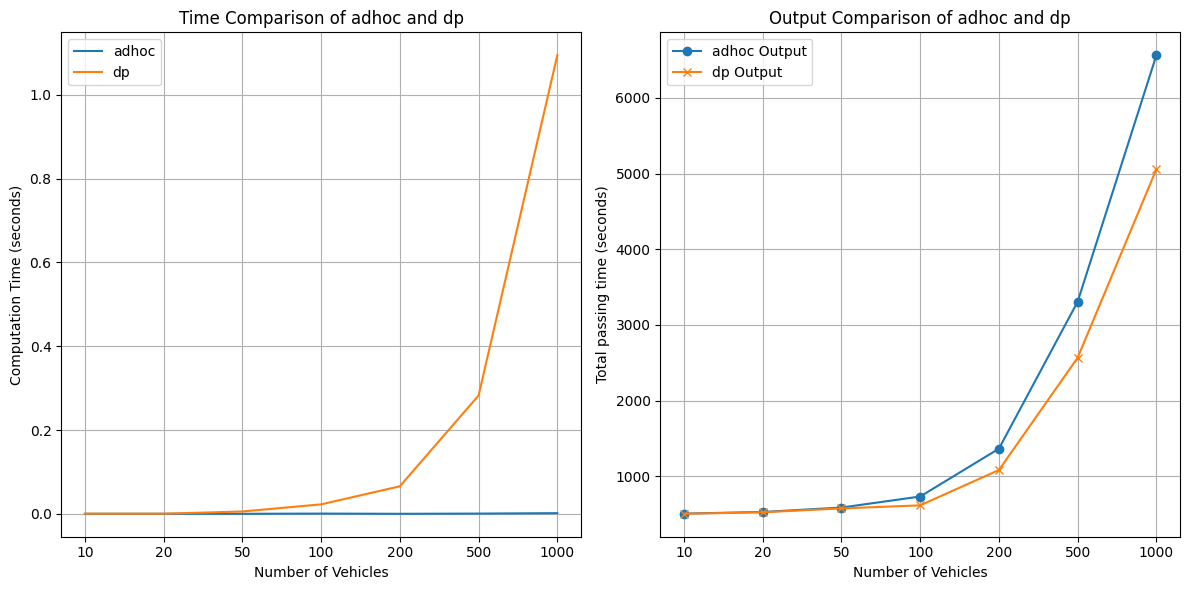

In [52]:
def compare_algorithms():
    input_sizes = [10 , 20 , 50 , 100 , 200 , 500 , 1000 ]  # Varying input sizes
    times_adhoc = []
    times_dp = []
    outputs_adhoc = []
    outputs_dp = []

    for size in input_sizes:
        
        xt,yt,x,y = [0]*4
        n = 4
        
        for i in range ( n ) :
            
            data = generate_test_case(size)

            start_time = time.time()
            result_adhoc = calculate_adhoc(data)
            end_time = time.time()
            xt += end_time - start_time
            x += result_adhoc

            start_time = time.time()
            result_dp = calculate_dp(data)
            end_time = time.time()
            yt += end_time - start_time
            y += result_dp
        
        times_adhoc.append(xt/n)
        times_dp.append(yt/n)
        outputs_adhoc.append(x/n)
        outputs_dp.append(y/n)



        

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(len(input_sizes)), times_adhoc, label='adhoc')
    plt.plot(range(len(input_sizes)), times_dp, label='dp')
    plt.xlabel('Number of Vehicles')
    plt.ylabel('Computation Time (seconds)')
    plt.title('Time Comparison of adhoc and dp')
    plt.xticks(range(len(input_sizes)), input_sizes) 
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(len(input_sizes)), outputs_adhoc, label='adhoc Output', marker='o')
    plt.plot(range(len(input_sizes)), outputs_dp, label='dp Output', marker='x')
    plt.xlabel('Number of Vehicles')
    plt.ylabel('Total passing time (seconds)')
    plt.title('Output Comparison of adhoc and dp')
    plt.xticks(range(len(input_sizes)), input_sizes) 
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

compare_algorithms()